In [1]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql.functions import col, to_date, when
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pyspark.sql.functions as F

# Create a SparkSession
spark = SparkSession.builder \
    .appName("Sales") \
    .getOrCreate()

# Read the CSV file into a DataFrame
df = spark.read.csv("C:/Big Data Project/dataset/Sales.csv", header=True, inferSchema=True)

In [2]:
# Show the DataFrame schema
df.printSchema()

# Display the first few rows of the DataFrame
df.show(10)

root
 |-- _c0: integer (nullable = true)
 |-- Unnamed: 0.1: integer (nullable = true)
 |-- Unnamed: 0: integer (nullable = true)
 |-- date_: date (nullable = true)
 |-- city_name: string (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- cart_id: integer (nullable = true)
 |-- dim_customer_key: integer (nullable = true)
 |-- procured_quantity: integer (nullable = true)
 |-- unit_selling_price: double (nullable = true)
 |-- total_discount_amount: double (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- total_weighted_landing_price: double (nullable = true)

+---+------------+----------+----------+---------+---------+---------+----------------+-----------------+------------------+---------------------+----------+----------------------------+
|_c0|Unnamed: 0.1|Unnamed: 0|     date_|city_name| order_id|  cart_id|dim_customer_key|procured_quantity|unit_selling_price|total_discount_amount|product_id|total_weighted_landing_price|
+---+------------+----------+-----

In [3]:
# To remove multiple columns by name
df = df.drop('_c0', 'Unnamed: 0.1', 'Unnamed: 0', 'cart_id')

# Show the updated DataFrame schema
df.printSchema()
# Display the first few rows of the DataFrame
df.show(10)

root
 |-- date_: date (nullable = true)
 |-- city_name: string (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- dim_customer_key: integer (nullable = true)
 |-- procured_quantity: integer (nullable = true)
 |-- unit_selling_price: double (nullable = true)
 |-- total_discount_amount: double (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- total_weighted_landing_price: double (nullable = true)

+----------+---------+---------+----------------+-----------------+------------------+---------------------+----------+----------------------------+
|     date_|city_name| order_id|dim_customer_key|procured_quantity|unit_selling_price|total_discount_amount|product_id|total_weighted_landing_price|
+----------+---------+---------+----------------+-----------------+------------------+---------------------+----------+----------------------------+
|2022-04-01|   Mumbai|112246974|        17995199|                1|             234.0|                  0.0|    344107|      

In [4]:
#before cleaning
df.count()

46706387

In [5]:
#after cleaning
#To drop rows with any null values
#Handle Missing Values: You can use the na functions to deal with nulls or missing values in various ways

df = df.na.drop()

In [6]:
#after cleaning
df.count()

46627032

In [7]:
#Remove Duplicates: To remove duplicate rows based on all or a subset of columns
# remove all duplicate rows

df = df.dropDuplicates()

In [8]:
#after cleaning
df.count()

46627032

In [9]:
#Rename columns:
df = df.withColumnRenamed('date_', 'purchase_date')
df = df.withColumnRenamed('procured_quantity', 'quantity')
df = df.withColumnRenamed('date_', 'purchase_date')

# Show the updated DataFrame schema
df.printSchema()

root
 |-- purchase_date: date (nullable = true)
 |-- city_name: string (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- dim_customer_key: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_selling_price: double (nullable = true)
 |-- total_discount_amount: double (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- total_weighted_landing_price: double (nullable = true)



In [10]:
# Create another SparkSession
spark = SparkSession.builder \
    .appName("products") \
    .getOrCreate()

# Read the CSV file into a DataFrame
df2 = spark.read.csv("C:/Big Data Project/dataset/products.csv", header=True, inferSchema=True)

In [11]:
# Show the DataFrame schema
df2.printSchema()

# Display the first few rows of the DataFrame
df2.show(10)

root
 |-- _c0: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- unit: string (nullable = true)
 |-- product_type: string (nullable = true)
 |-- brand_name: string (nullable = true)
 |-- manufacturer_name: string (nullable = true)
 |-- l0_category: string (nullable = true)
 |-- l1_category: string (nullable = true)
 |-- l2_category: string (nullable = true)
 |-- l0_category_id: string (nullable = true)
 |-- l1_category_id: integer (nullable = true)
 |-- l2_category_id: integer (nullable = true)

+---+----------+--------------------+------+------------+---------------+--------------------+-----------+------------+------------+--------------+--------------+--------------+
|_c0|product_id|        product_name|  unit|product_type|     brand_name|   manufacturer_name|l0_category| l1_category| l2_category|l0_category_id|l1_category_id|l2_category_id|
+---+----------+--------------------+------+------------+---------------+--

In [12]:
# To remove multiple columns by name
df2 = df2.drop('_c0', 'unit', 'l1_category', 'l2_category', 'l0_category_id', 'l1_category_id', 'l2_category_id')

# Show the updated DataFrame schema
df2.printSchema()
# Display the first few rows of the DataFrame
df2.show(10)

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- product_type: string (nullable = true)
 |-- brand_name: string (nullable = true)
 |-- manufacturer_name: string (nullable = true)
 |-- l0_category: string (nullable = true)

+----------+--------------------+------------+---------------+--------------------+-----------+
|product_id|        product_name|product_type|     brand_name|   manufacturer_name|l0_category|
+----------+--------------------+------------+---------------+--------------------+-----------+
|    476763|    Christmas - Card|        Card|           NULL|                 HOT|   Specials|
|    483436|Plum BodyLovin' H...|      Sample|Plum BodyLovin'|Pureplay Skin Sci...|   Specials|
|    476825|Diwali Gift Card ...|      Sample|           NULL|                 HOT|   Specials|
|    483438|Plum BodyLovin' T...|      Sample|Plum BodyLovin'|Pureplay Skin Sci...|   Specials|
|    480473|Flipkart Valentin...|        Card|       Flip

In [13]:
#before cleaning
df2.count()

32226

In [14]:
#after cleaning
#To drop rows with any null values
#Handle Missing Values: You can use the na functions to deal with nulls or missing values in various ways

df2 = df2.na.drop()

In [15]:
#after cleaning
df2.count()

29030

In [16]:
#Remove Duplicates: To remove duplicate rows based on all or a subset of columns
# remove all duplicate rows

df2 = df2.dropDuplicates()

In [17]:
#after cleaning
df2.count()

29030

In [18]:
# Rename columns:
df2 = df2.withColumnRenamed('l0_category', 'product_category')

# Show the updated DataFrame schema
df2.printSchema()

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- product_type: string (nullable = true)
 |-- brand_name: string (nullable = true)
 |-- manufacturer_name: string (nullable = true)
 |-- product_category: string (nullable = true)



In [20]:
# Joining df1 and df2 DataFrames and 'product_id' is the common column
# Join the DataFrames using the 'product_id' column as a list
joined_df = df.join(df2, ['product_id'])


In [21]:
joined_df.count()

34143216

In [22]:
# Show the updated DataFrame schema
joined_df.printSchema()
# Display the first few rows of the DataFrame
joined_df.show(10)

root
 |-- product_id: integer (nullable = true)
 |-- purchase_date: date (nullable = true)
 |-- city_name: string (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- dim_customer_key: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_selling_price: double (nullable = true)
 |-- total_discount_amount: double (nullable = true)
 |-- total_weighted_landing_price: double (nullable = true)
 |-- product_name: string (nullable = true)
 |-- product_type: string (nullable = true)
 |-- brand_name: string (nullable = true)
 |-- manufacturer_name: string (nullable = true)
 |-- product_category: string (nullable = true)

+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+------------+--------------------+--------------------+
|product_id|purchase_date|city_name| order_id|dim_customer_key|quantity|unit_selling_price|total_discount_

In [23]:
#data validation

#Read the final dataset count
joined_df.count()

34143216

In [24]:
# Data Validation - Date format check
dateFormat = "yyyy-MM-dd"

# Perform format check for purchase_date
# Add a new column 'purchase_date_valid' which flags invalid date formats as null
filtered_dataset = joined_df.withColumn('purchase_date_valid', to_date(col('purchase_date'), dateFormat))

# Filter out records with invalid dates if needed
filtered_dataset = filtered_dataset.filter(col('purchase_date_valid').isNotNull())



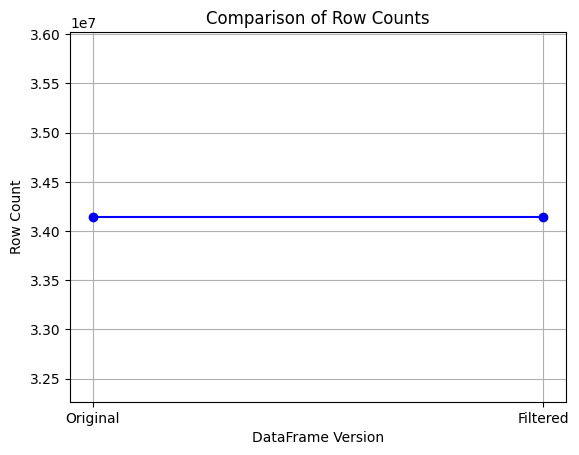

In [25]:
# Count the number of rows before and after filtering
original_count = joined_df.count()
filtered_count = filtered_dataset.count()

# Assuming you have collected the counts
counts = [original_count, filtered_count]
versions = ['Original', 'Filtered']

# Create a line graph
plt.plot(versions, counts, marker='o', linestyle='-', color='b')
plt.xlabel('DataFrame Version')
plt.ylabel('Row Count')
plt.title('Comparison of Row Counts')
plt.grid(True)
plt.show()


In [26]:
# Calculation Check for total_price
from pyspark.sql.functions import when
filtered_dataset = filtered_dataset.withColumn('calculated_total_price', col('quantity') * col('unit_selling_price') - col('total_discount_amount'))
filtered_dataset = filtered_dataset.withColumn('price_mismatch', when(col('total_weighted_landing_price') != col('calculated_total_price'), True).otherwise(False))

filtered_dataset.show(8)

+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+----------+--------------------+--------------------+-------------------+----------------------+--------------+
|product_id|purchase_date|city_name| order_id|dim_customer_key|quantity|unit_selling_price|total_discount_amount|total_weighted_landing_price|        product_name|        product_type|brand_name|   manufacturer_name|    product_category|purchase_date_valid|calculated_total_price|price_mismatch|
+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+----------+--------------------+--------------------+-------------------+----------------------+--------------+
|    443262|   2022-04-01|   HR-NCR|112247955|        14725039|       1|             249.0|                  0.0

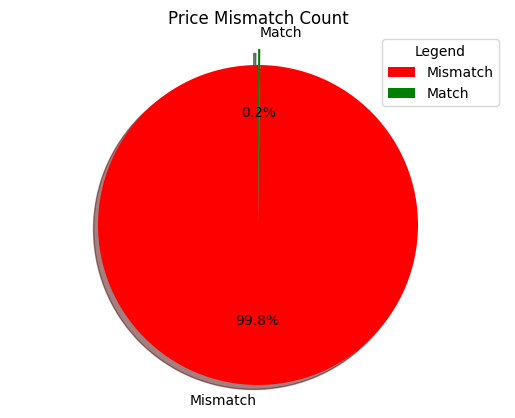

In [27]:
# Assuming filtered_dataset is my DataFrame after adding the 'price_mismatch' column
# Count the number of True and False values for price_mismatch
mismatch_count = filtered_dataset.groupBy('price_mismatch').count().collect()

# Prepare data for visualization
counts = [row['count'] for row in mismatch_count]

# Initially if there are both boolean values present for the price_mismatch column, then the counts list will take the first
# index as True counts and the second index as False counts
# So we will follow that order 
labels = ['Mismatch', 'Match']  # Mismatch reperesents the True values and Match represents the second one which is False values
colors = ['red', 'green']       # Red reperesents the True values and Green represents the second one which is False values

if len(counts) == 1:                    #this condition is to check if there is only 1 boolean value (True/False)
    if mismatch_count[0][0]:            #if True then we will count the mismatched values and add another list item as 0 counts to be False value
        labels = ['Mismatch', 'Match']
        colors = ['red', 'green']
        counts.append(0)
    else:
        labels = ['Match', 'Mismatch']  #if False then we will count the matched values and add another list item as 0 counts to be True value
        colors = ['green', 'red']
        counts.append(0)

# Plotting the pie chart
explode = (0, 0.1)  # only "explode" the 2nd slice (i.e. 'Mismatch')

plt.pie(counts, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Price Mismatch Count')

# Adding a legend
plt.legend(labels, loc="best", title="Legend")

plt.show()

# Filtering out the wrong values


In [28]:
# Filter out the wrong values
corrected_filtered_dataset = filtered_dataset.withColumn('total_weighted_landing_price',
                             when(col('price_mismatch'), col('calculated_total_price'))
                             .otherwise(col('total_weighted_landing_price')))


corrected_filtered_dataset.show(6)

+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+----------+--------------------+--------------------+-------------------+----------------------+--------------+
|product_id|purchase_date|city_name| order_id|dim_customer_key|quantity|unit_selling_price|total_discount_amount|total_weighted_landing_price|        product_name|        product_type|brand_name|   manufacturer_name|    product_category|purchase_date_valid|calculated_total_price|price_mismatch|
+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+----------+--------------------+--------------------+-------------------+----------------------+--------------+
|    443262|   2022-04-01|   HR-NCR|112247955|        14725039|       1|             249.0|                  0.0

In [29]:
# Now lets check and match again
#update the price mismatch column
corrected_filtered_dataset = corrected_filtered_dataset.withColumn('price_mismatch', when(col('total_weighted_landing_price') != col('calculated_total_price'), True).otherwise(False))

corrected_filtered_dataset.show(8)

+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+----------+--------------------+--------------------+-------------------+----------------------+--------------+
|product_id|purchase_date|city_name| order_id|dim_customer_key|quantity|unit_selling_price|total_discount_amount|total_weighted_landing_price|        product_name|        product_type|brand_name|   manufacturer_name|    product_category|purchase_date_valid|calculated_total_price|price_mismatch|
+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+----------+--------------------+--------------------+-------------------+----------------------+--------------+
|    443262|   2022-04-01|   HR-NCR|112247955|        14725039|       1|             249.0|                  0.0

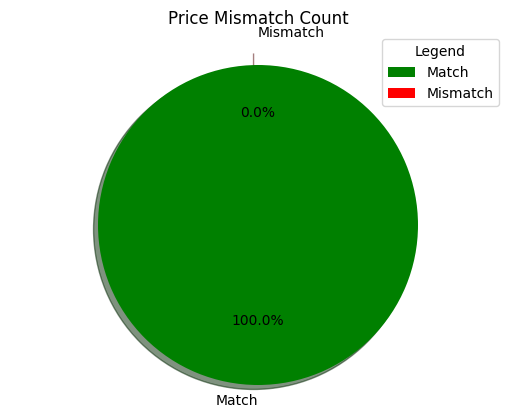

In [30]:
# lets plot the pie chart again and see the changes
mismatch_count = corrected_filtered_dataset.groupBy('price_mismatch').count().collect()


# Prepare data for visualization

counts = [row['count'] for row in mismatch_count]

# Initially if there are both boolean values present for the price_mismatch column, then the counts list will take the first
# index as True counts and the second index as False counts
# So we will follow that order 

labels = ['Mismatch', 'Match']   # Mismatch reperesents the True values and Match represents the second one which is False values
colors = ['red', 'green']        # Red reperesents the True values and Green represents the second one which is False values


if len(counts) == 1:            #this condition is to check if there is only 1 boolean value (True/False)
    if mismatch_count[0][0]:
        labels = ['Mismatch', 'Match']      #if True then we will count the mismatched values and add another list item as 0 counts to be False value
        colors = ['red', 'green']
        counts.append(0)
    else:
        labels = ['Match', 'Mismatch']      #if False then we will count the mismatched values and add another list item as 0 counts to be True value
        colors = ['green', 'red']
        counts.append(0)


# Plotting the pie chart

explode = (0, 0.1)  # only "explode" the 2nd slice (i.e. 'Mismatch')

plt.pie(counts, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Price Mismatch Count')

# Adding a legend
plt.legend(labels, loc="best", title="Legend")

plt.show()

In [31]:
#now lets drop the extra columns added for validation
corrected_filtered_dataset = corrected_filtered_dataset.drop('purchase_date_valid', 'calculated_total_price', 'price_mismatch')
corrected_filtered_dataset.show(5)

+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+----------+--------------------+--------------------+
|product_id|purchase_date|city_name| order_id|dim_customer_key|quantity|unit_selling_price|total_discount_amount|total_weighted_landing_price|        product_name|        product_type|brand_name|   manufacturer_name|    product_category|
+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+----------+--------------------+--------------------+
|    443262|   2022-04-01|   HR-NCR|112247955|        14725039|       1|             249.0|                  0.0|                       249.0|Nivea Pure Gentle...|                Talc|     Nivea| Nivea India Pvt Ltd|       Personal Care|
|    368445|   2022-04-01|   HR-NCR|112266922|  

In [32]:
#getting the correlation matrix
columns = ["quantity", "unit_selling_price", "total_discount_amount", "total_weighted_landing_price"]

# Convert the list to a DataFrame
df = corrected_filtered_dataset.select(columns)

# Show the DataFrame
df.show(5)




+--------+------------------+---------------------+----------------------------+
|quantity|unit_selling_price|total_discount_amount|total_weighted_landing_price|
+--------+------------------+---------------------+----------------------------+
|       1|             249.0|                  0.0|                       249.0|
|       1|             100.0|                  0.0|                       100.0|
|       1|              44.0|                  0.0|                        44.0|
|       1|             115.0|                  0.0|                       115.0|
|       1|              52.0|                  0.0|                        52.0|
+--------+------------------+---------------------+----------------------------+
only showing top 5 rows



In [33]:
# Convert to vector column first
vector_col = "corr_features"
assembler = VectorAssembler(inputCols=columns, outputCol=vector_col)
df_vector = assembler.transform(df).select(vector_col)

# Get correlation matrix
matrix = Correlation.corr(df_vector, vector_col).head()

# Extract the values from the correlation matrix
corr_array = matrix[0].toArray()

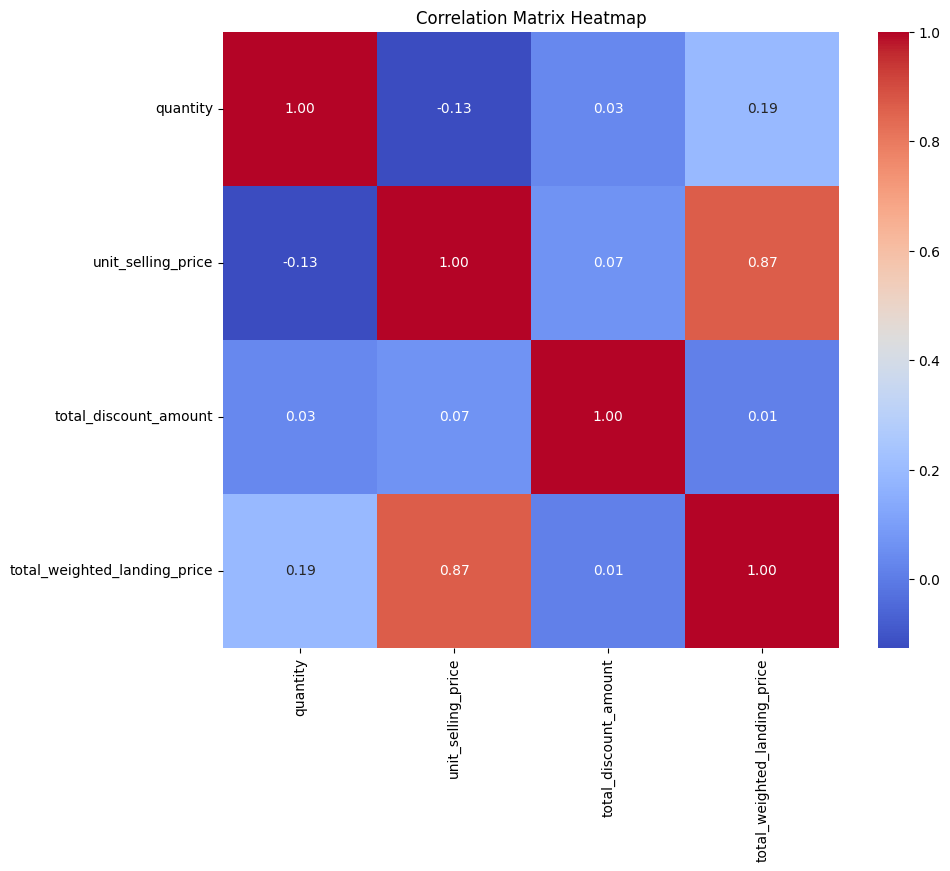

In [34]:
# Assuming 'corr_array' is the NumPy array from the previous steps
corr_df = pd.DataFrame(corr_array, columns=columns, index=columns)

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap='coolwarm', square=True)

# Add title
plt.title('Correlation Matrix Heatmap')

# Show plot
plt.show()

In [ ]:
# Now lets save the cleaned final dataset as csv file before proceeding to the case studies

In [35]:
# Specify the path where you want to save the CSV file
output_path = 'C:/Big Data Project/dataset/cleaned_dataset.csv'

# Coalesce the DataFrame to 1 partition
single_part_df = corrected_filtered_dataset.coalesce(1)

# Write the single-partitioned DataFrame to a CSV file
single_part_df.write.csv(output_path, header=True)


In [1]:
#end
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql.functions import col, to_date, when
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler
import pyspark.sql.functions as F

In [2]:
# Start of case studies
#Read the final dataset
# Create a SparkSession
spark = SparkSession.builder \
    .appName("CaseStudy1") \
    .getOrCreate()

# Read the CSV file into a DataFrame
case1 = spark.read.csv("C:/Big Data Project/dataset/cleaned_dataset/cleaned_dataset.csv", header=True, inferSchema=True)


# Show the updated DataFrame schema
case1.printSchema()
# Display the first few rows of the DataFrame
case1.show(10)

root
 |-- product_id: integer (nullable = true)
 |-- purchase_date: date (nullable = true)
 |-- city_name: string (nullable = true)
 |-- order_id: integer (nullable = true)
 |-- dim_customer_key: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_selling_price: double (nullable = true)
 |-- total_discount_amount: double (nullable = true)
 |-- total_weighted_landing_price: double (nullable = true)
 |-- product_name: string (nullable = true)
 |-- product_type: string (nullable = true)
 |-- brand_name: string (nullable = true)
 |-- manufacturer_name: string (nullable = true)
 |-- product_category: string (nullable = true)

+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+------------+--------------------+--------------------+
|product_id|purchase_date|city_name| order_id|dim_customer_key|quantity|unit_selling_price|total_discount_

In [12]:
#Which manufacturer was the most popular in terms of getting orders than others? (Ranking based on items ordered)

# Group by 'manufacturer' and count 'order_id'
manufacturer_counts = case1.groupBy("manufacturer_name").count()

# Rename the 'count' column to 'order_count' for clarity
manufacturer_counts = manufacturer_counts.withColumnRenamed("count", "order_count")

# Order the results in descending order of 'order_count'
top_manufacturers = manufacturer_counts.orderBy(col("order_count").desc())

# Show the top 5 manufacturers
top_manufacturers.show(5)




+--------------------+-----------+
|   manufacturer_name|order_count|
+--------------------+-----------+
|                 HOT|    2762333|
|               GCMMF|    2688754|
|Hindustan Unileve...|    1461404|
|         ITC Limited|    1379121|
|          Pepsi Food|    1179478|
+--------------------+-----------+
only showing top 5 rows



C:\Users\User\AppData\Local\Temp\ipykernel_4496\1747172975.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


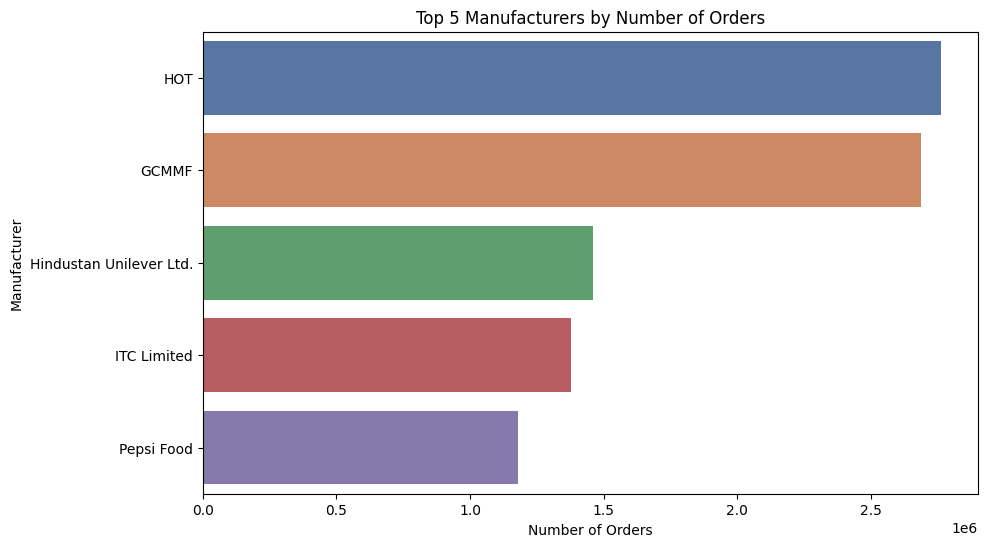

In [15]:


# Assuming 'top_manufacturers' is your PySpark DataFrame from the previous steps
# Convert to Pandas DataFrame
top_manufacturers_pd = top_manufacturers.toPandas()
# Assuming 'top_manufacturers_pd' is your Pandas DataFrame
plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    x='order_count', 
    y='manufacturer_name', 
    data=top_manufacturers_pd.head(5),
    palette='deep'  # This is a valid palette name
)

# Add labels and title
plt.xlabel('Number of Orders')
plt.ylabel('Manufacturer')
plt.title('Top 5 Manufacturers by Number of Orders')
plt.show()




In [27]:
#Case study 2: How many cities created orders more than 100,000 times? (If I can’t find any will reduce the cap/limit) 
from wordcloud import WordCloud

# Group by 'city_name' and count 'order_id'
city_order_counts = case1.groupBy("city_name").count()

# Rename the 'count' column to 'order_count' for clarity
city_order_counts = city_order_counts.withColumnRenamed("count", "order_count")

# Filter cities with more than 100,000 orders
cities_with_large_orders = city_order_counts.filter(col("order_count") >= 100000)

# Collect the results
final_cities = cities_with_large_orders.collect()

# Print the city names
for city in final_cities:
    print(city["city_name"])
    
# Convert to Pandas DataFrame for visualization
cities_with_large_orders_pd = cities_with_large_orders.toPandas()


Mumbai
Delhi
Bengaluru
HR-NCR


In [28]:
# Get the cities name with order numbers 
cities_with_large_orders_pd

,city_name,order_count
0,Mumbai,2892532
1,Delhi,16610829
2,Bengaluru,6263147
3,HR-NCR,8376708


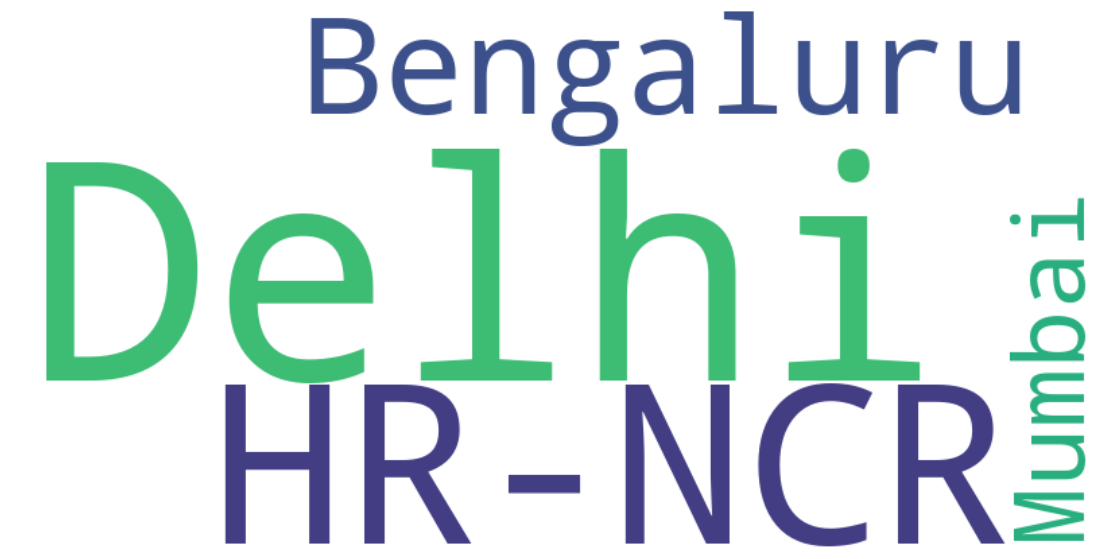

In [29]:

# Prepare the data for the word cloud: create a dictionary of city names and order counts
city_freq = {row['city_name']: row['order_count'] for index, row in cities_with_large_orders_pd.iterrows()}

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(city_freq)

# Display the generated word cloud
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [2]:
#Case study 3: Which brands are offering the highest discount in Bengaluru, Mumbai and Delhi? 

#Filter the DataFrame for the cities of interest
cities = ["Bengaluru", "Mumbai", "Delhi"]
df_filtered = case1.filter(case1.city_name.isin(cities))


In [11]:
df_filtered.show(5)

+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+----------+--------------------+--------------------+
|product_id|purchase_date|city_name| order_id|dim_customer_key|quantity|unit_selling_price|total_discount_amount|total_weighted_landing_price|        product_name|        product_type|brand_name|   manufacturer_name|    product_category|
+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+--------------------+----------+--------------------+--------------------+
|     11186|   2022-04-01|    Delhi|112307176|        11288483|       1|              44.0|                  0.0|                      35.102|Catch Cumin Powde...|Cumin Powder / Je...|     Catch|  D S Group (Spices)|Dry Fruits, Masal...|
|    439935|   2022-04-01|Bengaluru|112306752|  

In [12]:
#Partition the data based on city_name to optimize the map-reduce operation
from pyspark.sql.functions import col
df_partitioned = df_filtered.repartition("city_name")
df_partitioned = df_partitioned.select(col("city_name"),col("brand_name"),col("total_discount_amount"))
df_partitioned.show(10)

+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+----------------+--------------------+--------------------+--------------------+
|product_id|purchase_date|city_name| order_id|dim_customer_key|quantity|unit_selling_price|total_discount_amount|total_weighted_landing_price|        product_name|    product_type|          brand_name|   manufacturer_name|    product_category|
+----------+-------------+---------+---------+----------------+--------+------------------+---------------------+----------------------------+--------------------+----------------+--------------------+--------------------+--------------------+
|    362796|   2022-04-03|   Mumbai|112793548|        17009937|       1|              10.0|                  0.0|                    8.546999|Britannia Little ...|         Biscuit|Britannia Little ...|           Britannia|   Bakery & Biscuits|
|    127891|   2022-04-0

In [16]:
#Map-Reduce to Find Maximum Discount: Use the groupBy and agg functions to find the maximum discount by brand in each city.

from pyspark.sql import functions as F

df_max_discount = df_partitioned.groupBy("city_name", "brand_name")\
                                .agg(F.max("total_discount_amount").alias("max_discount"))



In [17]:
df_max_discount.show(5)

+---------+--------------------+------------+
|city_name|          brand_name|max_discount|
+---------+--------------------+------------+
|   Mumbai|Britannia Little ...|        60.0|
|   Mumbai|               Peppy|        78.0|
|   Mumbai|                 7UP|        75.0|
|   Mumbai|           Carnivore|       276.0|
|   Mumbai|   Aashirvaad Select|       354.0|
+---------+--------------------+------------+
only showing top 5 rows



In [19]:
#Find the Top Brands for Each City: For each city, order the results by the maximum discount in descending order and get the top brand(s).
from pyspark.sql.window import Window
df_result = df_max_discount.withColumn("rank", F.rank().over(Window.partitionBy("city_name").orderBy(F.desc("max_discount"))))\
                           .filter("rank = 1")\
                           .drop("rank")


In [23]:
df_result.show(12, truncate=False)


+---------+---------------+------------+
|city_name|brand_name     |max_discount|
+---------+---------------+------------+
|Mumbai   |Amul           |1500.0      |
|Delhi    |India Gate     |1500.0      |
|Delhi    |Kellogg's      |1500.0      |
|Delhi    |Borges         |1500.0      |
|Delhi    |Gopaljee Ananda|1500.0      |
|Delhi    |Safe Harvest   |1500.0      |
|Bengaluru|Nandini        |1500.0      |
|Bengaluru|MamyPoko Pants |1500.0      |
|Bengaluru|GTS            |1500.0      |
|Bengaluru|Gold Flake     |1500.0      |
|Bengaluru|Marlboro       |1500.0      |
|Bengaluru|Enfamil        |1500.0      |
+---------+---------------+------------+



+----------------+--------------+
|dim_customer_key|total_spending|
+----------------+--------------+
|        12296465|      397001.0|
|        15147146|      185676.0|
|         4831341|      178704.0|
|         5271409|      166903.0|
|        12751874|      162886.0|
|         4414315|      160175.0|
|         1326909|      154209.0|
|        19568656|      145255.0|
|        14251312|      134121.0|
|        14794780|      120912.0|
+----------------+--------------+



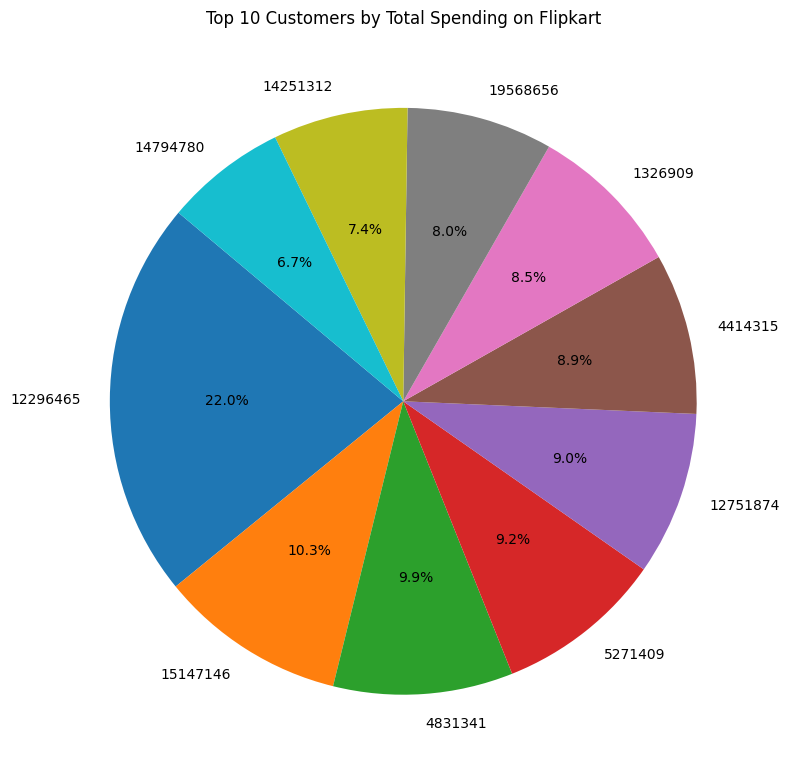

In [3]:
# case study 4: What are some of the target customers that spend the most money on Flipkart? 

# Create a Spark session
spark = SparkSession.builder \
    .appName("case4") \
    .getOrCreate()

# Load the CSV file into a DataFrame
case4 = spark.read.csv("C:/Big Data Project/dataset/cleaned_dataset/cleaned_dataset.csv", header=True, inferSchema=True)


# Group by customer_id and sum the total_landing_price for each customer
customer_spending = case4.groupBy("dim_customer_key").sum("total_weighted_landing_price").withColumnRenamed("sum(total_weighted_landing_price)", "total_spending")

# Get the top 10 customers based on total spending
top_10_customers = customer_spending.orderBy(col("total_spending").desc()).limit(10)

# Show the top 10 customers
top_10_customers.show()

# visualize the scenerio
# Extract the customer IDs and total spending amounts from the DataFrame
customer_ids = [row.dim_customer_key for row in top_10_customers.collect()]
total_spending = [row.total_spending for row in top_10_customers.collect()]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(total_spending, labels=customer_ids, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.title('Target Customers by Total Spending on Flipkart')
plt.tight_layout()

# Show the plot
plt.show()


# Stop the Spark session
spark.stop()